In [3]:
# IMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('mahasiswa.csv')

df.head()

,tahun_masuk,bulan_lulus,ipk,jumlah_mk_gagal,sks_lulus,status_skripsi,jumlah_bimbingan,ontime
0,2018,11,3.21,2,128,2,8,1
1,2017,6,3.62,0,111,4,12,1
2,2018,5,3.66,0,134,3,9,1
3,2018,12,3.69,1,124,3,13,1
4,2018,7,2.99,7,116,0,7,1


Data Understanding

In [4]:
# 1. IDENTIFIKASI STRUKTUR DATASET

print("Jumlah Baris dan Kolom Dataset:")
print(df.shape)

print("\nInformasi Dataset:")
df.info()

print("\nStatistik Dataset:")
display(df.describe())

print("\nCek Missing Value:")
print(df.isnull().sum())

Jumlah Baris dan Kolom Dataset:
(600, 8)

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   tahun_masuk       600 non-null    int64  
 1   bulan_lulus       600 non-null    int64  
 2   ipk               600 non-null    float64
 3   jumlah_mk_gagal   600 non-null    int64  
 4   sks_lulus         600 non-null    int64  
 5   status_skripsi    600 non-null    int64  
 6   jumlah_bimbingan  600 non-null    int64  
 7   ontime            600 non-null    int64  
dtypes: float64(1), int64(7)
memory usage: 37.6 KB

Statistik Dataset:


,tahun_masuk,bulan_lulus,ipk,jumlah_mk_gagal,sks_lulus,status_skripsi,jumlah_bimbingan,ontime
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,2017.496667,6.398333,3.001917,3.106667,129.791667,1.890000,6.718333,0.438333
std,1.720928,3.389515,0.446323,2.171747,11.637898,1.276956,3.513247,0.496597
min,2015.000000,1.000000,2.000000,0.000000,110.000000,0.000000,1.000000,0.000000
25%,2016.000000,4.000000,2.740000,1.000000,120.000000,1.000000,4.000000,0.000000
50%,2018.000000,6.000000,3.010000,3.000000,130.000000,2.000000,7.000000,0.000000
75%,2019.000000,9.000000,3.290000,5.000000,140.000000,3.000000,9.000000,1.000000
max,2020.000000,12.000000,4.000000,7.000000,149.000000,4.000000,14.000000,1.000000



Cek Missing Value:
tahun_masuk         0
bulan_lulus         0
ipk                 0
jumlah_mk_gagal     0
sks_lulus           0
status_skripsi      0
jumlah_bimbingan    0
ontime              0
dtype: int64


In [6]:
# 2. IDENTIFIKASI FEATURE (X) DAN TARGET / LABEL (Y)
# fitur (x) untuk data input prediksi
# label (y) untuk hasil klasifikasi/prediksi

# Feature / Kriteria / History
X = df[['tahun_masuk',
        'ipk',
        'jumlah_mk_gagal',
        'sks_lulus',
        'status_skripsi',
        'jumlah_bimbingan']]

# Target / Label
y = df['ontime']

print("===== FEATURE (X) =====")
display(X.head())

print("\n===== TARGET / LABEL (Y) =====")
display(y.head())

print("\nKeterangan Target:")
print("Ontime = 1 --> Lulus <= 4 Tahun")
print("Ontime = 0 --> Lulus > 4 Tahun")

===== FEATURE (X) =====


,tahun_masuk,ipk,jumlah_mk_gagal,sks_lulus,status_skripsi,jumlah_bimbingan
0,2018,3.21,2,128,2,8
1,2017,3.62,0,111,4,12
2,2018,3.66,0,134,3,9
3,2018,3.69,1,124,3,13
4,2018,2.99,7,116,0,7



===== TARGET / LABEL (Y) =====


0    1
1    1
2    1
3    1
4    1
Name: ontime, dtype: int64


Keterangan Target:
Ontime = 1 --> Lulus <= 4 Tahun
Ontime = 0 --> Lulus > 4 Tahun


Distribusi Target Ontime:
ontime
0    337
1    263
Name: count, dtype: int64


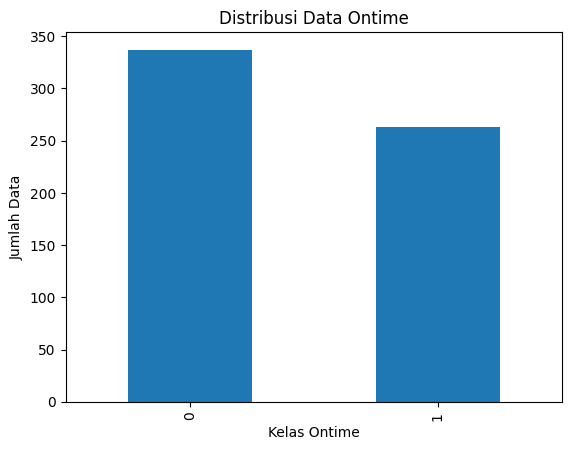

In [7]:
# 3. ANALISIS DISTRIBUSI DATA

print("Distribusi Target Ontime:")
print(df['ontime'].value_counts())

df['ontime'].value_counts().plot(kind='bar')

plt.title("Distribusi Data Ontime")
plt.xlabel("Kelas Ontime")
plt.ylabel("Jumlah Data")

plt.show()

In [8]:
# 4. RULE-BASED SYSTEM

df['rule_based_ontime'] = (
    (df['ipk'] >= 3.00) &
    (df['jumlah_mk_gagal'] <= 2) &
    (df['jumlah_bimbingan'] > 10) &
    (df['status_skripsi'] < 7)
).astype(int)

print("Hasil Rule-Based System:")
display(df[['ipk',
            'jumlah_mk_gagal',
            'jumlah_bimbingan',
            'status_skripsi',
            'rule_based_ontime']].head(10))

print("\nDistribusi Rule-Based:")
print(df['rule_based_ontime'].value_counts())

print("\nKeterangan:")
print("Ontime = 1 jika memenuhi rule")
print("Ontime = 0 jika tidak memenuhi rule")

# menampilkan hanya data yang memenuhi rule (nilai = 1)
data_rule_1 = df[df['rule_based_ontime'] == 1]
display(data_rule_1.head(10))

Hasil Rule-Based System:


,ipk,jumlah_mk_gagal,jumlah_bimbingan,status_skripsi,rule_based_ontime
0,3.21,2,8,2,0
1,3.62,0,12,4,1
2,3.66,0,9,3,0
3,3.69,1,13,3,1
4,2.99,7,7,0,0
5,3.16,2,2,0,0
6,3.51,0,8,3,0
7,3.17,2,2,0,0
8,3.10,3,9,1,0
9,3.40,0,10,3,0



Distribusi Rule-Based:
rule_based_ontime
0    532
1     68
Name: count, dtype: int64

Keterangan:
Ontime = 1 jika memenuhi rule
Ontime = 0 jika tidak memenuhi rule


,tahun_masuk,bulan_lulus,ipk,jumlah_mk_gagal,sks_lulus,status_skripsi,jumlah_bimbingan,ontime,rule_based_ontime
1,2017,6,3.62,0,111,4,12,1,1
3,2018,12,3.69,1,124,3,13,1,1
17,2017,3,3.16,2,137,3,11,1,1
24,2017,8,3.36,1,114,4,12,1,1
28,2020,10,3.37,1,111,4,12,0,1
30,2020,8,3.38,1,134,4,11,1,1
34,2015,12,3.38,1,128,3,14,1,1
44,2019,12,3.25,2,141,3,13,1,1
47,2019,5,3.75,0,125,3,14,1,1
71,2018,5,3.82,1,137,4,14,1,1


Data preparation

In [9]:
# 1. DATA CLEANING

# cek missing value / data kosong
print("Cek Missing Value:")
print(df.isnull().sum())

# hapus missing value
df = df.dropna()

# cek data duplikat
print("\nJumlah Data Duplikat:")
print(df.duplicated().sum())

# hapus data duplikat
df = df.drop_duplicates()

# samakan format data
df['tahun_masuk'] = df['tahun_masuk'].astype(int)
df['bulan_lulus'] = df['bulan_lulus'].astype(int)
df['jumlah_mk_gagal'] = df['jumlah_mk_gagal'].astype(int)
df['sks_lulus'] = df['sks_lulus'].astype(int)
df['status_skripsi'] = df['status_skripsi'].astype(int)
df['jumlah_bimbingan'] = df['jumlah_bimbingan'].astype(int)
df['ontime'] = df['ontime'].astype(int)

# tampilkan hasil setelah cleaning
print("\nJumlah Data Setelah Cleaning:")
print(df.shape)

print("\nTipe Data Setelah Cleaning:")
print(df.dtypes)

print("\nData Setelah Cleaning:")
display(df.head())

Cek Missing Value:
tahun_masuk          0
bulan_lulus          0
ipk                  0
jumlah_mk_gagal      0
sks_lulus            0
status_skripsi       0
jumlah_bimbingan     0
ontime               0
rule_based_ontime    0
dtype: int64

Jumlah Data Duplikat:
0

Jumlah Data Setelah Cleaning:
(600, 9)

Tipe Data Setelah Cleaning:
tahun_masuk            int64
bulan_lulus            int64
ipk                  float64
jumlah_mk_gagal        int64
sks_lulus              int64
status_skripsi         int64
jumlah_bimbingan       int64
ontime                 int64
rule_based_ontime      int64
dtype: object

Data Setelah Cleaning:


,tahun_masuk,bulan_lulus,ipk,jumlah_mk_gagal,sks_lulus,status_skripsi,jumlah_bimbingan,ontime,rule_based_ontime
0,2018,11,3.21,2,128,2,8,1,0
1,2017,6,3.62,0,111,4,12,1,1
2,2018,5,3.66,0,134,3,9,1,0
3,2018,12,3.69,1,124,3,13,1,1
4,2018,7,2.99,7,116,0,7,1,0


In [10]:
# 2. Data Transformation

# ENCODING DATA KATEGORIKAL
# memastikan status_skripsi bertipe integer
df['status_skripsi'] = df['status_skripsi'].astype(int)

print("Tipe Data Setelah Encoding:")
print(df.dtypes)


# NORMALISASI DATA
from sklearn.preprocessing import MinMaxScaler
# membuat object normalisasi
scaler = MinMaxScaler()

# kolom yang dinormalisasi
kolom_normalisasi = [
    'tahun_masuk',
    'ipk',
    'jumlah_mk_gagal',
    'sks_lulus',
    'status_skripsi',
    'jumlah_bimbingan',
]

# proses normalisasi
df[kolom_normalisasi] = scaler.fit_transform(df[kolom_normalisasi])

print("Data Setelah Normalisasi:")
display(df.head())

Tipe Data Setelah Encoding:
tahun_masuk            int64
bulan_lulus            int64
ipk                  float64
jumlah_mk_gagal        int64
sks_lulus              int64
status_skripsi         int64
jumlah_bimbingan       int64
ontime                 int64
rule_based_ontime      int64
dtype: object
Data Setelah Normalisasi:


,tahun_masuk,bulan_lulus,ipk,jumlah_mk_gagal,sks_lulus,status_skripsi,jumlah_bimbingan,ontime,rule_based_ontime
0,0.6,11,0.605,0.285714,0.461538,0.50,0.538462,1,0
1,0.4,6,0.810,0.000000,0.025641,1.00,0.846154,1,1
2,0.6,5,0.830,0.000000,0.615385,0.75,0.615385,1,0
3,0.6,12,0.845,0.142857,0.358974,0.75,0.923077,1,1
4,0.6,7,0.495,1.000000,0.153846,0.00,0.461538,1,0


In [11]:
# 3. FEATURE ENGINEERING

# membuat fitur rata IP
df['rata_ip'] = df['ipk']

# membuat fitur progress skripsi / SKS
df['progress_skripsi_sks'] = (
    df['status_skripsi'] + df['sks_lulus']
) / 2

# membuat fitur tren IP
df['tren_ip'] = df['ipk'] * 1.05

print("Fitur Baru Hasil Feature Engineering:")
display(df[['ipk',
            'sks_lulus',
            'status_skripsi',
            'rata_ip',
            'progress_skripsi_sks',
            'tren_ip']].head())

Fitur Baru Hasil Feature Engineering:


,ipk,sks_lulus,status_skripsi,rata_ip,progress_skripsi_sks,tren_ip
0,0.605,0.461538,0.50,0.605,0.480769,0.63525
1,0.810,0.025641,1.00,0.810,0.512821,0.85050
2,0.830,0.615385,0.75,0.830,0.682692,0.87150
3,0.845,0.358974,0.75,0.845,0.554487,0.88725
4,0.495,0.153846,0.00,0.495,0.076923,0.51975


In [12]:
# 4. FEATURE SELECTION

# memilih fitur yang relevan
fitur_relevan = [
    'tahun_masuk',
    'ipk',
    'jumlah_mk_gagal',
    'sks_lulus',
    'status_skripsi',
    'jumlah_bimbingan',
    'rata_ip',
    'progress_skripsi_sks',
    'tren_ip'
]

# feature / input
X = df[fitur_relevan]

# target / label
y = df['ontime']

print("Feature yang digunakan:")
display(X.head())

print("\nTarget / Label:")
display(y.head())

Feature yang digunakan:


,tahun_masuk,ipk,jumlah_mk_gagal,sks_lulus,status_skripsi,jumlah_bimbingan,rata_ip,progress_skripsi_sks,tren_ip
0,0.6,0.605,0.285714,0.461538,0.50,0.538462,0.605,0.480769,0.63525
1,0.4,0.810,0.000000,0.025641,1.00,0.846154,0.810,0.512821,0.85050
2,0.6,0.830,0.000000,0.615385,0.75,0.615385,0.830,0.682692,0.87150
3,0.6,0.845,0.142857,0.358974,0.75,0.923077,0.845,0.554487,0.88725
4,0.6,0.495,1.000000,0.153846,0.00,0.461538,0.495,0.076923,0.51975



Target / Label:


0    1
1    1
2    1
3    1
4    1
Name: ontime, dtype: int64

Modeling (Machine Learning)

In [13]:
# 1. Split Data
from sklearn.model_selection import train_test_split

# feature dan target
X = df[[
    'tahun_masuk',
    'ipk',
    'jumlah_mk_gagal',
    'sks_lulus',
    'status_skripsi',
    'jumlah_bimbingan',
    'rata_ip',
    'progress_skripsi_sks',
    'tren_ip'
]]

y = df['ontime']

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# gabung feature + target
train_data = X_train.copy()
train_data['ontime'] = y_train

test_data = X_test.copy()
test_data['ontime'] = y_test

# simpan csv
train_data.to_csv('datatrain.csv', index=False) #melatih model
test_data.to_csv('datatest.csv', index=False) #menguji model

# output
print("Training:", train_data.shape)
print("Testing :", test_data.shape)

display(train_data.head())
display(test_data.head())

Training: (480, 10)
Testing : (120, 10)


,tahun_masuk,ipk,jumlah_mk_gagal,sks_lulus,status_skripsi,jumlah_bimbingan,rata_ip,progress_skripsi_sks,tren_ip,ontime
145,1.0,0.660,0.000000,0.846154,1.00,0.538462,0.660,0.923077,0.69300,1
9,0.8,0.700,0.000000,0.589744,0.75,0.692308,0.700,0.669872,0.73500,1
375,1.0,0.330,0.714286,0.717949,0.25,0.461538,0.330,0.483974,0.34650,0
523,0.0,0.585,0.285714,0.666667,0.25,0.615385,0.585,0.458333,0.61425,1
188,0.2,0.905,0.142857,0.358974,0.75,0.923077,0.905,0.554487,0.95025,1


,tahun_masuk,ipk,jumlah_mk_gagal,sks_lulus,status_skripsi,jumlah_bimbingan,rata_ip,progress_skripsi_sks,tren_ip,ontime
110,0.4,0.300,1.000000,0.820513,0.25,0.461538,0.300,0.535256,0.31500,0
419,0.6,0.630,0.428571,0.153846,1.00,0.769231,0.630,0.576923,0.66150,1
565,0.4,0.455,0.857143,1.000000,0.25,0.000000,0.455,0.625000,0.47775,0
77,0.8,0.930,0.142857,0.461538,0.75,0.846154,0.930,0.605769,0.97650,1
181,0.4,0.495,0.857143,0.153846,0.50,0.307692,0.495,0.326923,0.51975,0


In [14]:
# 2. Training Model / Model AI
from sklearn.tree import DecisionTreeClassifier

# membuat model Decision Tree
model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# melatih model menggunakan data training
model.fit(X_train, y_train)

print("Model Decision Tree berhasil dilatih")

Model Decision Tree berhasil dilatih


In [15]:
# 3. PREDIKSI DATA TESTING

# melakukan prediksi
y_pred = model.predict(X_test)

print("Hasil Prediksi:")
print(y_pred[:10])

Hasil Prediksi:
[0 1 0 1 0 1 0 1 0 1]


Evaluation

In [16]:
# 1. metode evaluasi

# ACCURACY
from sklearn.metrics import accuracy_score
# menghitung accuracy
accuracy = accuracy_score(y_test, y_pred)
# ubah ke persen
accuracy_persen = accuracy * 100
print("Nilai Accuracy:")
print(f"{accuracy_persen:.2f}%")

# PRECISION
from sklearn.metrics import precision_score
# menghitung precision
precision = precision_score(y_test, y_pred)
precision_persen = precision * 100
print("Nilai Precision:")
print(f"Precision: {precision_persen:.2f}%")

# RECALL
from sklearn.metrics import recall_score
# menghitung recall
recall = recall_score(y_test, y_pred)
recall_persen = recall * 100
print("Nilai Recall:")
print(f"Recall   : {recall_persen:.2f}%")

# CONFUSION MATRIX
from sklearn.metrics import confusion_matrix
# membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Nilai Accuracy:
70.83%
Nilai Precision:
Precision: 67.92%
Nilai Recall:
Recall   : 66.67%
Confusion Matrix:
[[49 17]
 [18 36]]


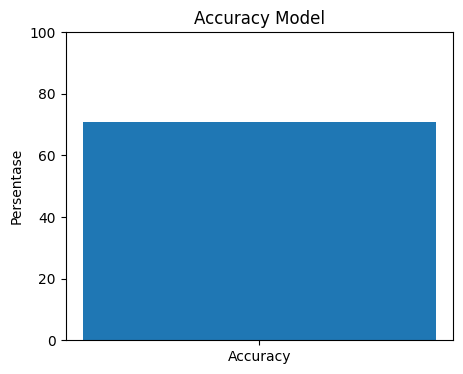

In [17]:
# BAR CHART ACCURACY
import matplotlib.pyplot as plt

akurasi = accuracy * 100

plt.figure(figsize=(5,4))

plt.bar(['Accuracy'], [akurasi])

plt.ylabel('Persentase')

plt.title('Accuracy Model')

plt.ylim(0,100)

plt.show()

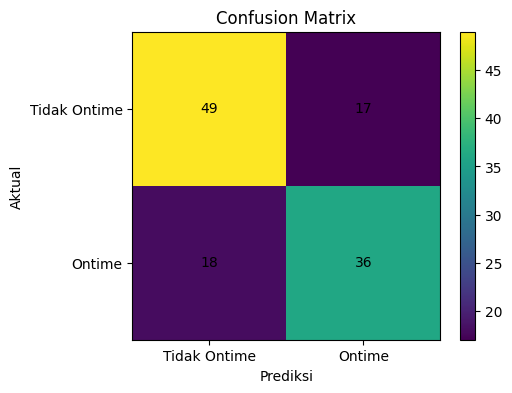

In [20]:
# CONFUSION MATRIX HEATMAP
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.colorbar()

labels = ['Tidak Ontime', 'Ontime']

plt.xticks([0,1], labels)
plt.yticks([0,1], labels)

# menampilkan angka pada kotak
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.show()

Feature Importance:


,Fitur,Importance
1,ipk,0.568263
5,jumlah_bimbingan,0.134144
3,sks_lulus,0.125709
2,jumlah_mk_gagal,0.067605
7,progress_skripsi_sks,0.040535
8,tren_ip,0.020393
6,rata_ip,0.019169
4,status_skripsi,0.014916
0,tahun_masuk,0.009266


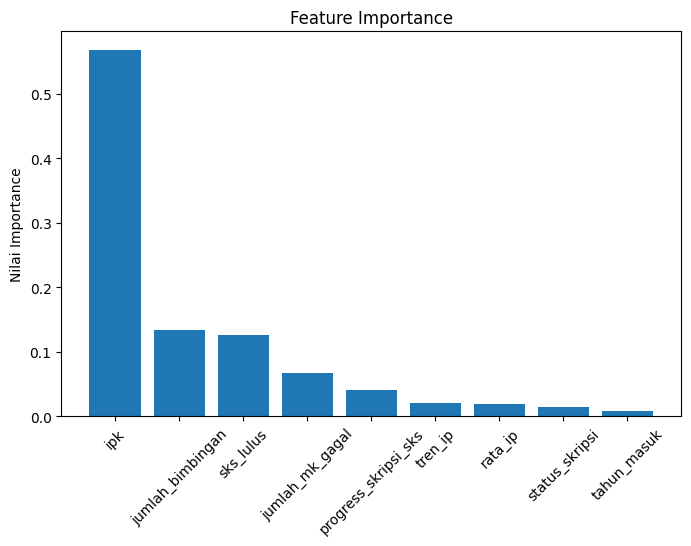

In [22]:
# FEATURE IMPORTANCE

importance = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': model.feature_importances_
})

# urutkan dari terbesar
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("Feature Importance:")
display(importance)


# VISUALISASI FEATURE IMPORTANCE

plt.figure(figsize=(8,5))

plt.bar(
    importance['Fitur'],
    importance['Importance']
)

plt.xticks(rotation=45)

plt.ylabel('Nilai Importance')

plt.title('Feature Importance')

plt.show()

Deployment

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import joblib

X = df[['tahun_masuk',
        'ipk',
        'jumlah_mk_gagal',
        'sks_lulus',
        'status_skripsi',
        'jumlah_bimbingan']]

y = df['ontime']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

joblib.dump(model, 'model_kelulusan.pkl')

print("Model final berhasil disimpan")

Model final berhasil disimpan
